# Exploratory Data Analysis (EDA):

In [1]:
import sys
from pathlib import Path
# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)


Project root: c:\Users\joetn\Real-Time_IoT_2022_Quantized_Auto_Encoder


In [22]:
from src.data import load_raw
from src.eda import effect_size

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.compose import ColumnTransformer

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Load dataset and save to data/raw
# Recommended (requires pyarrow)
X, y, df = load_raw(save=True, fmt="parquet")

# Slower alternative (no dependencies)
# X, y, df = load_raw(fmt="csv")

df.head()

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,target
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish


# Data Validation & Exploratory Data Analysis (EDA):

1. **Absence of Amazon_Alexa normal traffic**: During dataset initialization and validation as shown in @tbl-rtiot-shapes, @tbl-rtiot-missing, @tbl-rtiot-target-dist, and @fig-rtiot-target-dist, we observed that the **Amazon_Alexa traffic category was entirely absent** from the available RT-IoT data. According to the original dataset documentation, Amazon_Alexa represents a normal traffic class containing approximately 86,842 observations and plays an important role in balancing the distribution between normal and attack traffic as shown in @tbl-rtiot-target-binary. Its absence substantially **reduces the volume of normal samples**, creating challenges for the intended anomaly detection framework, particularly for autoencoder training, which relies exclusively on learning normal traffic behavior.

    Because intrusion detection datasets capture complex relationships across more than 80 network-flow features, generating synthetic traffic that preserves realistic temporal and statistical structure would be difficult and could introduce artificial patterns. After unsuccessful attempts to obtain the complete dataset, we therefore refine the project scope to focus on IoT device traffic excluding the original voice-assistant (Amazon_Alexa) normal class.

    To maintain methodological rigor while avoiding synthetic data generation, we construct a balanced dataset through **random downsampling of the majority attack class**. All available normal traffic samples are retained, and an equal number of attack flows are selected without replacement. This approach preserves authentic network behavior while mitigating class imbalance for subsequent model training and evaluation.
2. **Categorical Feature Inspection:** A data type audit in @tbl-rtiot-dtype-summary, @tbl-rtiot-string-features, and @tbl-rtiot-string-cardinality , identified two string-based features within the dataset: `proto` and `service`. Cardinality analysis shows that `proto` contains three unique values, while `service` contains ten unique values, indicating that both variables represent low-cardinality categorical attributes rather than identifiers. This suggests that these features encode meaningful protocol and network service information rather than sample-specific identifiers that could introduce data leakage.

    Given their limited number of categories and clear semantic interpretation, these **features should be retained and incorporated into the modeling pipeline** through appropriate categorical encoding (e.g., one-hot encoding). Because Logistic Regression and subsequent models operate on numeric inputs, encoding will allow the models to leverage protocol-level differences in network behavior while preserving interpretability. No evidence of high-cardinality or near-unique string features was observed, reducing concerns about unintended memorization or leakage from identifier-like variables.
3. **Analysis of Feature Skewness:** To assess whether additional preprocessing is necessary prior to model training, feature skewness was evaluated across all numeric variables. @tbl-rtiot-skewness-top identified **66 numeric features with skewness over 2.0**, followed by histogram comparisons between raw and log-transformed distributions for the top 8 most skewed numeric features in @fig-rtiot-log-transform-justification.
    - Extreme Positive Skewness in Network Traffic Features: 

        - Many traffic-volume and packet aggregation features exhibit **extremely large skewness values**, exceeding 200–300 in magnitude. Notably:

          - `bwd_bulk_bytes`
          - `bwd_bulk_packets`
          - `active.std`
          - `*_pkts_payload.tot`
          - `*_pkts_tot`
          - `bwd_header_size_tot`

        - These values indicate highly asymmetric distributions characterized by:

          - a large concentration of observations near zero,
          - long right tails containing rare but extremely large values,
          - and heavy-tailed behavior typical of bursty network traffic.

        Such distributions are expected in real-world network telemetry, where most flows are small while a minority of flows generate disproportionately large traffic volumes.

    - Visual Evidence from Histogram Comparisons:

        The histogram comparisons demonstrate that raw feature distributions are strongly compressed near zero, with extreme outliers dominating the scale. As a result:

        - meaningful variation among typical observations becomes visually indistinguishable,
        - variance is dominated by a small number of extreme flows,
        - and statistical assumptions underlying linear models are violated.

        After applying the $\log(1 + x)$ transformation:

        - long tails are compressed,
        - distributions become more symmetric,
        - variance is stabilized across observations,
        - and structure within the bulk of the data becomes visible.

        Importantly, the transformation preserves ordering while reducing the influence of extreme magnitudes.

    Accordingly, subsequent modeling experiments apply a $\log(1+x)$ transformation to highly skewed traffic features prior to scaling and classification. Overall, this preprocessing step ensures that downstream performance improvements arise from meaningful traffic behavior rather than artifacts of feature magnitude.

In [ ]:
# Establish variables for later use
RANDOM_STATE = 42
NORMAL_CLASSES = {"Thing_Speak", "MQTT_Publish", "Wipro_bulb"}
TARGET_COL = "target"

# Focus on numeric features for correlation annd plotting
X_num = df.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number])
NUMERIC_FEATURES = X_num.columns.tolist()

# Create masks for normal vs attack classes
NORMAL_MASK = df[TARGET_COL].isin(NORMAL_CLASSES)
ATTACK_MASK = ~NORMAL_MASK

In [7]:
#| label: tbl-rtiot-shapes
#| tbl-cap: "Shapes of X and y. X columns (83) are limited."

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X columns:", list(X.columns)[:10], "...")
print("y column:", y.name)


X shape: (123117, 83)
y shape: (123117,)
X columns: ['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec'] ...
y column: target


In [9]:
#| label: tbl-rtiot-missing
#| tbl-cap: "Check for missing values."

dataset_missing = pd.DataFrame({
    "dataset": ["X (features)", "y (target)"],
    "missing_values": [X.isna().sum().sum(), y.isna().sum()],
    "missing_rate": [
        X.isna().sum().sum() / X.size,
        y.isna().sum() / len(y)
    ]
})

display(dataset_missing.set_index("dataset"))

,missing_values,missing_rate
dataset,,
X (features),0,0.0
y (target),0,0.0


In [10]:
#| label: tbl-rtiot-target-dist
#| tbl-cap: "Target class distribution table."

target_counts = (
    y.value_counts()
    .rename_axis("target")
    .to_frame("count")
)

target_counts["rate"] = target_counts["count"] / target_counts["count"].sum()
display(target_counts)

,count,rate
target,,
DOS_SYN_Hping,94659,0.768854
Thing_Speak,8108,0.065856
ARP_poisioning,7750,0.062948
MQTT_Publish,4146,0.033675
NMAP_UDP_SCAN,2590,0.021037
NMAP_XMAS_TREE_SCAN,2010,0.016326
NMAP_OS_DETECTION,2000,0.016245
NMAP_TCP_scan,1002,0.008139
DDOS_Slowloris,534,0.004337


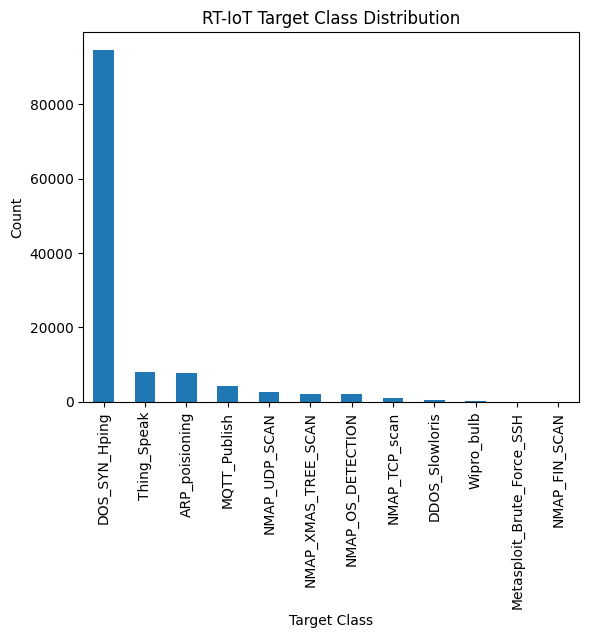

In [14]:
#| label: fig-rtiot-target-dist
#| fig-cap: "Target class distribution plot."

class_counts = df["target"].value_counts().sort_values(ascending=False)

plt.figure()
class_counts.plot(kind="bar")
plt.title("RT-IoT Target Class Distribution")
plt.ylabel("Count")
plt.xlabel("Target Class")
plt.show()

In [ ]:
#| label: tbl-rtiot-target-binary
#| tbl-cap: "Binary label distribution (0=normal, 1=attack)."

# 1 = attack, 0 = normal
y_bin = (~y.isin(NORMAL_CLASSES)).astype(int)

# Build a single clean summary table
class_counts = y_bin.value_counts().sort_index().rename_axis("class").to_frame("count")
class_counts["rate"] = class_counts["count"] / class_counts["count"].sum()

display(class_counts)


,count,rate
class,,
0,12507,0.101586
1,110610,0.898414


In [ ]:
#| label: tbl-rtiot-dtype-summary
#| tbl-cap: "Data type summary (excluding target column)."

dtype_summary = (
    X.dtypes
        .value_counts()
        .rename_axis("dtype")
        .reset_index(name="count")
)

display(dtype_summary)

,dtype,count
0,float64,47
1,int64,34
2,str,2


In [ ]:
#| label: tbl-rtiot-string-features
#| tbl-cap: "String features in the dataset."

STR_COLS = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

display(
    pd.DataFrame({"string_feature": STR_COLS})
)

,string_feature
0,proto
1,service


In [ ]:
#| label: tbl-rtiot-string-cardinality
#| tbl-cap: "String features and their unique values."

string_cardinality = (
    df[STR_COLS]
    .nunique()
    .sort_values(ascending=False)
    .rename("unique_values")
    .rename_axis("feature")
    .reset_index()
)

display(string_cardinality)

,feature,unique_values
0,service,10
1,proto,3


In [19]:
#| label: tbl-rtiot-skewness-filtered
#| tbl-cap: "Features exceeding skewness threshold of 2.0 (absolute value)"

SKEW_THRESHOLD = 2.0

skewness = (
    X_num.skew(numeric_only=True)
        .abs()
        .sort_values(ascending=False)
)

SKEWED_FEATURES = skewness[skewness > SKEW_THRESHOLD].index.tolist()

display(
    skewness[skewness > SKEW_THRESHOLD]
        .rename("abs_skewness")
        .rename_axis("feature")
        .reset_index()
)

,feature,abs_skewness
0,bwd_bulk_bytes,340.497528
1,bwd_bulk_packets,340.490987
2,active.std,287.992755
3,bwd_pkts_payload.tot,280.814630
4,flow_pkts_payload.tot,271.972274
...,...,...
61,flow_FIN_flag_count,5.127096
62,bwd_init_window_size,4.271062
63,flow_pkts_payload.std,4.188075
64,flow_pkts_payload.min,3.738574


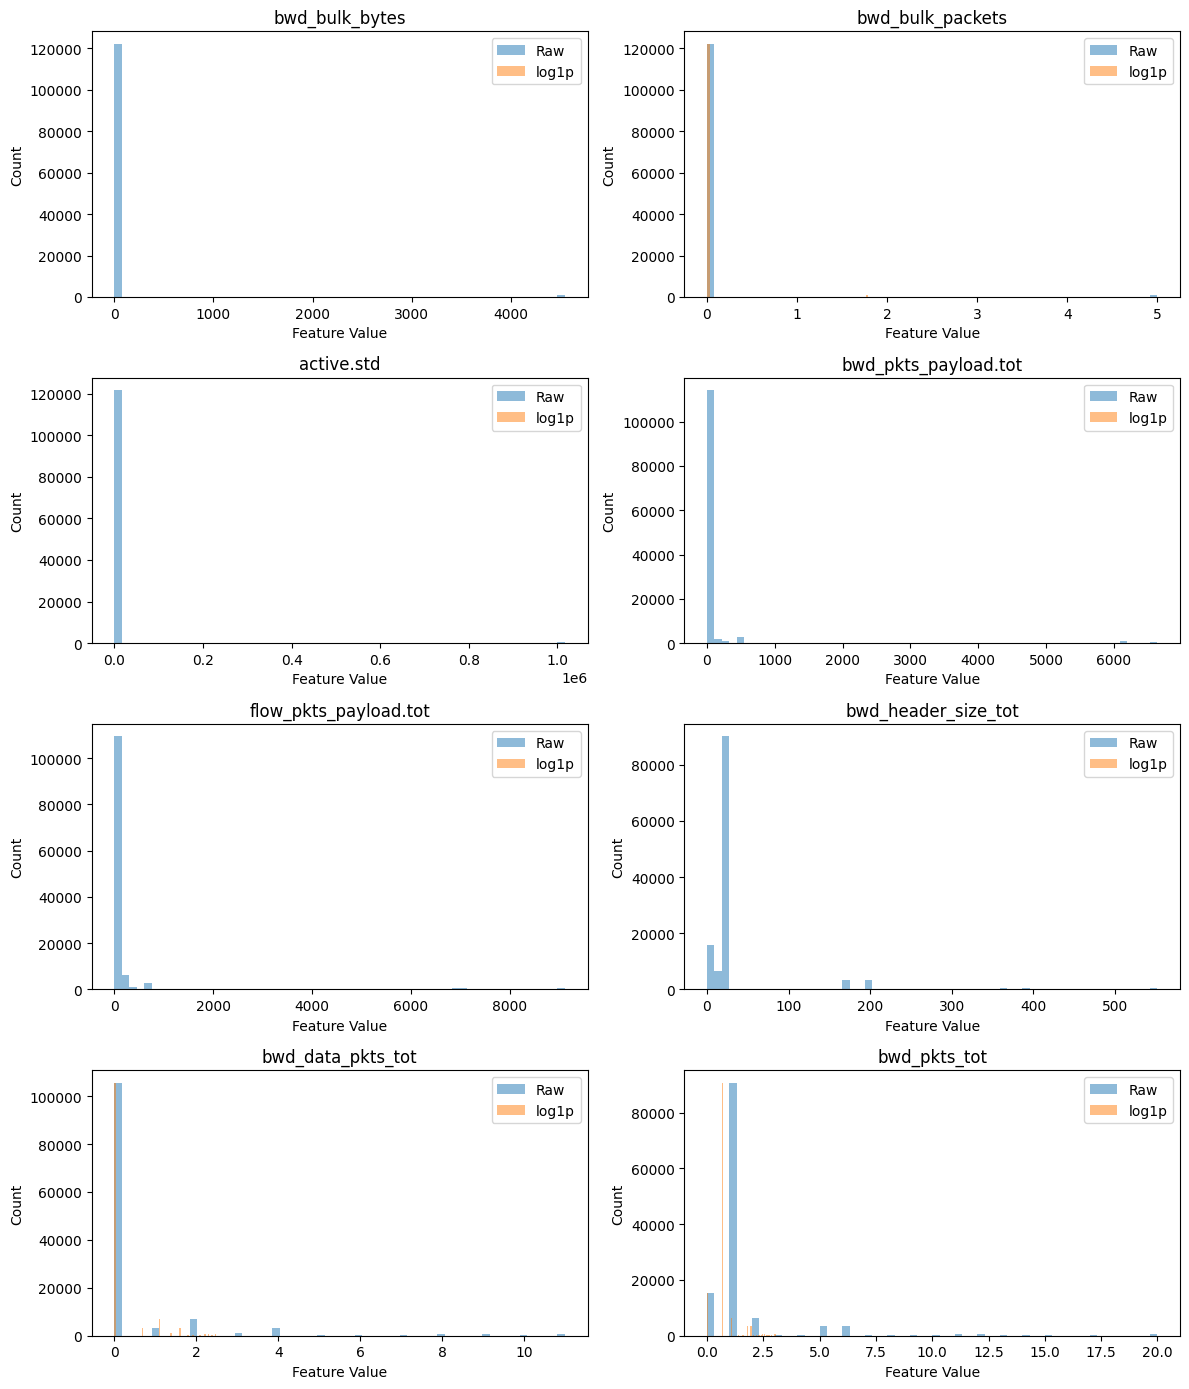

In [20]:
#| label: fig-rtiot-log-transform-justification
#| fig-cap: "Histogram comparison of raw vs log-transformed distributions for the top 8 most skewed features."

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

TOP_SKEW_FEATURES = SKEWED_FEATURES[:8]

for ax, col in zip(axes, TOP_SKEW_FEATURES):

    raw = pd.to_numeric(df[col], errors="coerce").dropna()

    # clip extreme tail
    upper = raw.quantile(0.995)
    raw = raw.clip(upper=upper)

    logv = np.log1p(raw)

    ax.hist(raw, bins=60, alpha=0.5, label="Raw")
    ax.hist(logv, bins=60, alpha=0.5, label="log1p")

    ax.set_title(col)
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

## Identifying Class-Separating Features

To better understand which features distinguish normal and attack traffic, we rank features using a **Standardized Mean Difference (SMD)** measure aka Cohen's d, a filter-based feature selection approach that quantifies class separability independent of model assumptions.

For each **numeric feature**, we compute a standardized difference between the normal and attack distributions:

$$
d = \frac{|\mu_{\text{normal}} - \mu_{\text{attack}}|}{\sigma_{\text{pooled}}}
$$

where the pooled standard deviation summarizes variability across both classes:

$$
\sigma_{\text{pooled}} =
\sqrt{\frac{\sigma_{\text{normal}}^{2} + \sigma_{\text{attack}}^{2}}{2}}
$$

And:

- $\mu_{\text{normal}}$ — mean feature value for normal traffic  
- $\mu_{\text{attack}}$ — mean feature value for attack traffic  
- $\sigma_{\text{pooled}}$ — pooled standard deviation across both classes  
- $d$ — standardized separation (effect size)

This metric quantifies how strongly a feature separates the two classes independent of scale. Features with larger effect sizes indicate **greater distributional separation between normal and attack traffic** and are therefore more informative for visualization and downstream modeling analysis as shown in @tbl-rtiot-effect-sizes.

The top-ranked features are selected as **class-separating features** and used in the following exploratory visualizations and analysis.

In [23]:
#| label: tbl-rtiot-effect-sizes
#| tbl-cap: "Top 10 features by effect size (numeric only)"

TOP_K = 10
EPS = 1e-12   # small stabilizer

# Create a column->score function
effect_size = effect_size(df, NORMAL_MASK, ATTACK_MASK, eps=EPS)

effect_scores = (
    X_num.columns.to_series()
    .apply(effect_size)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
)

TOP_FEATURES = effect_scores.head(TOP_K).index

display(
    effect_scores.head(10)
        .rename("Standardized Mean Difference")
        .rename_axis("Features")
        .reset_index()
)

,Features,Standardized Mean Difference
0,fwd_pkts_payload.min,2.738131
1,fwd_pkts_payload.avg,2.140473
2,fwd_init_window_size,1.666699
3,fwd_pkts_per_sec,1.493684
4,flow_pkts_per_sec,1.493501
5,bwd_pkts_per_sec,1.493306
6,bwd_init_window_size,1.471090
7,payload_bytes_per_second,1.435030
8,active.min,1.054205
9,fwd_subflow_pkts,0.965146


## Analysis of Class-Separating Features

To better understand how normal and attack traffic differ, kernel density estimates (KDEs) were plotted in @fig-rtiot-kde for the top class-separating features identified using standardized mean difference (SMD). These visualizations compare the empirical distributions of normal and attack samples for each feature.

1. Clear Distributional Separation:

    Across multiple features, attack traffic exhibits distinct statistical behavior compared to normal traffic. In particular:

    - Packet-rate features (`*_pkts_per_sec`, `flow_pkts_per_sec`, `bwd_pkts_per_sec`) show strong magnitude shifts between classes.
    - Payload statistics (`fwd_pkts_payload.min`, `fwd_pkts_payload.avg`, `payload_bytes_per_second`) demonstrate highly concentrated attack distributions with limited overlap.
    - TCP window size features (`*_init_window_size`) reveal substantially different operating ranges between normal and attack traffic.
    - Flow activity and subflow metrics (`active.min`, `fwd_subflow_pkts`) further distinguish attack behavior through tightly clustered value regions.

    In many cases, the **attack distribution forms an extremely narrow peak while normal traffic remains broader and multimodal**, indicating reduced variability within attack-generated flows.

2. Behavioral Differences in Network Traffic:

    The observed separation suggests that attacks modify fundamental traffic dynamics rather than subtle statistical properties. Specifically, attack flows tend to exhibit:

    - highly regular packet transmission rates,
    - consistent payload characteristics,
    - constrained TCP window configurations, and
    - structured subflow behavior.

    These patterns are consistent with **automated or scripted attack generation**, which produces repeatable traffic signatures compared to naturally varying user-driven network activity.

3. Low Overlap Between Classes:

    Several features display near-disjoint density regions, with attack samples concentrated within narrow intervals while normal traffic spans a wider range of values. This indicates that **individual features already encode strong discriminatory signal**, reducing reliance on complex feature interactions or nonlinear transformations for class separation.

4. Implications for Downstream Modeling:

    The presence of strong class separation at the feature level suggests that **linear decision boundaries may capture much of the discriminative structure** present in the dataset. Consequently, a simple supervised baseline model is well justified before introducing more complex representation-learning approaches such as autoencoders.

    Importantly, these findings reflect meaningful behavioral differences between normal and attack traffic patterns captured by the RT-IoT 2022 dataset rather than evidence of data leakage.

    Overall, the exploratory analysis demonstrates that a subset of packet-rate, payload, window-size, and flow-activity features provides substantial statistical separation between classes. These results establish an empirical foundation for subsequent modeling experiments and help explain why relatively simple classifiers may achieve strong performance on this dataset.

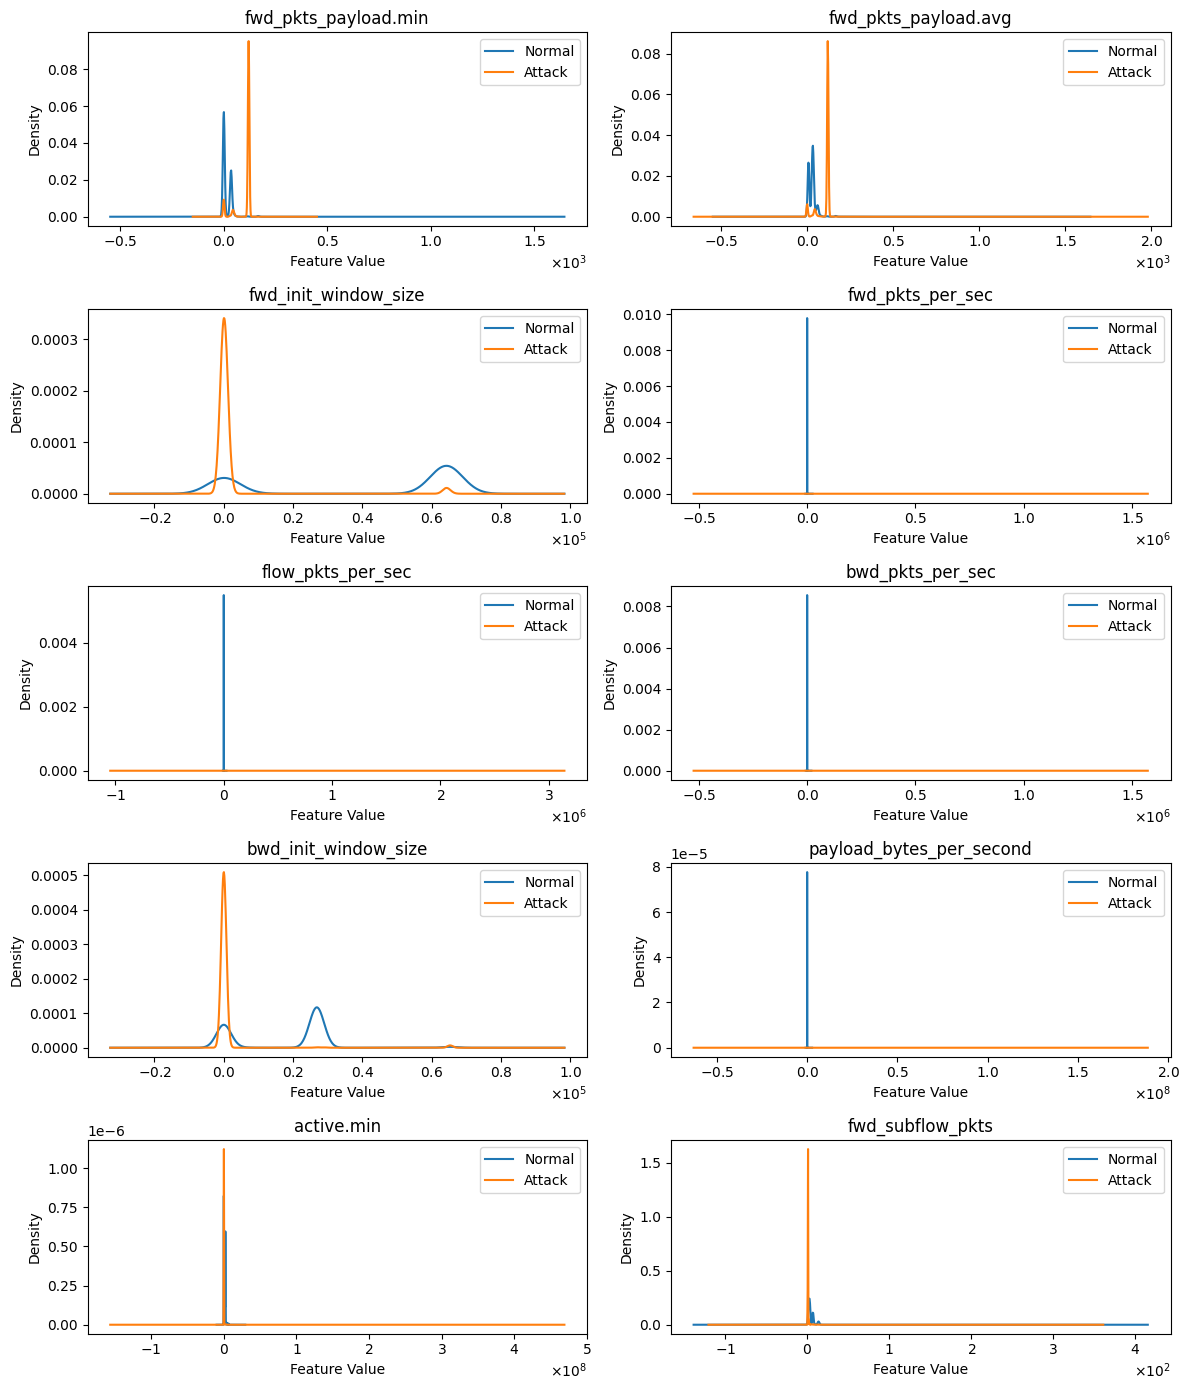

In [24]:
#| label: fig-rtiot-kde
#| fig-cap: "KDE plots of top features by effect size"

fig, axes = plt.subplots(5, 2, figsize=(12, 14))
axes = axes.flatten()

for ax, col in zip(axes, TOP_FEATURES):

    df.loc[NORMAL_MASK, col].plot(kind="kde", ax=ax, label="Normal")
    df.loc[ATTACK_MASK, col].plot(kind="kde", ax=ax, label="Attack")

    # Titles and labels
    ax.set_title(col)
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Density")

    # Improve tick readability for large network values
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0,0))

    ax.legend()

plt.tight_layout()
plt.show()

## Correlation Structure of Top Class-Separating Features

@fig-rtiot-corr-heatmap presents the Pearson correlation matrix for the top class-separating numeric features identified during exploratory analysis. The heatmap reveals several clear structural patterns that provide insight into multicollinearity and behavioral groupings within the RT-IoT 2022 dataset. @tbl-rtiot-vif-summary and @fig-rtiot-vif-top10 also show that many of their VIF scores are extreme. **68 of the 80 numeric features carry extreme multicollinearity** (VIF > 10). These analyses allow us to draw the following conclusions:

1. **Strong Feature Clustering and Redundancy:**

    The most prominent observation in the heatmap is the presence of distinct **blocks of highly correlated features** (correlation coefficients approaching ±1). These clusters indicate that multiple variables capture closely related aspects of the same underlying network behavior rather than independent signals.

    In particular:

    - Packet-rate features (`*_pkts_per_sec`) exhibit near-perfect positive correlation with one another, suggesting they are derived from common traffic counters.
    - Inter-arrival time statistics (`flow_iat.*`, `fwd_iat.*`, `idle.*`) form a dense correlation block, reflecting shared temporal characteristics of network flows.
    - Payload and header-size measurements also display moderate-to-strong correlations, indicating overlapping representations of packet structure.

    This redundancy implies that many high-ranking features encode similar information about traffic intensity and timing dynamics.

2. Behavioral Grouping of Network Characteristics:

    The correlation structure naturally separates features into interpretable behavioral categories:

    - **Transmission intensity:** packet rates and payload throughput metrics.
    - **Temporal dynamics:** inter-arrival times, idle durations, and activity statistics.
    - **Protocol and structural properties:** window sizes and header-related features.

    These groupings suggest that attack behavior manifests through coordinated changes across multiple related measurements rather than isolated feature shifts.

3. **Limited Independence Among Top Predictors:** Relatively few features (12) appear statistically independent (VIF <= 10). **High correlations indicate substantial multicollinearity**, meaning that including many correlated variables may not significantly increase predictive power but can **increase model complexity and computational cost**. 

4. **Implications for Feature Selection and Modeling:** The observed correlation structure **supports the use of feature reduction** prior to deployment. Because many variables measure similar traffic properties, a smaller subset of representative features can likely preserve most predictive information while improving efficiency. For linear models such as Logistic Regression, correlated predictors are **partially mitigated through L2 regularization**; however, reducing redundancy remains **beneficial for interpretability and resource-constrained deployment** scenarios.

5. **Connection to Dataset Characteristics:** The clustered correlations reflect the engineered nature of network-flow datasets, where multiple statistics are computed from the same packet stream. As a result, these **high correlation does not indicate noise but rather repeated measurements** of shared underlying traffic processes. Overall, the correlation analysis demonstrates that the RT-IoT 2022 dataset contains strong but highly redundant signals, reinforcing the motivation for dimensionality reduction and efficient feature selection in subsequent modeling stages.

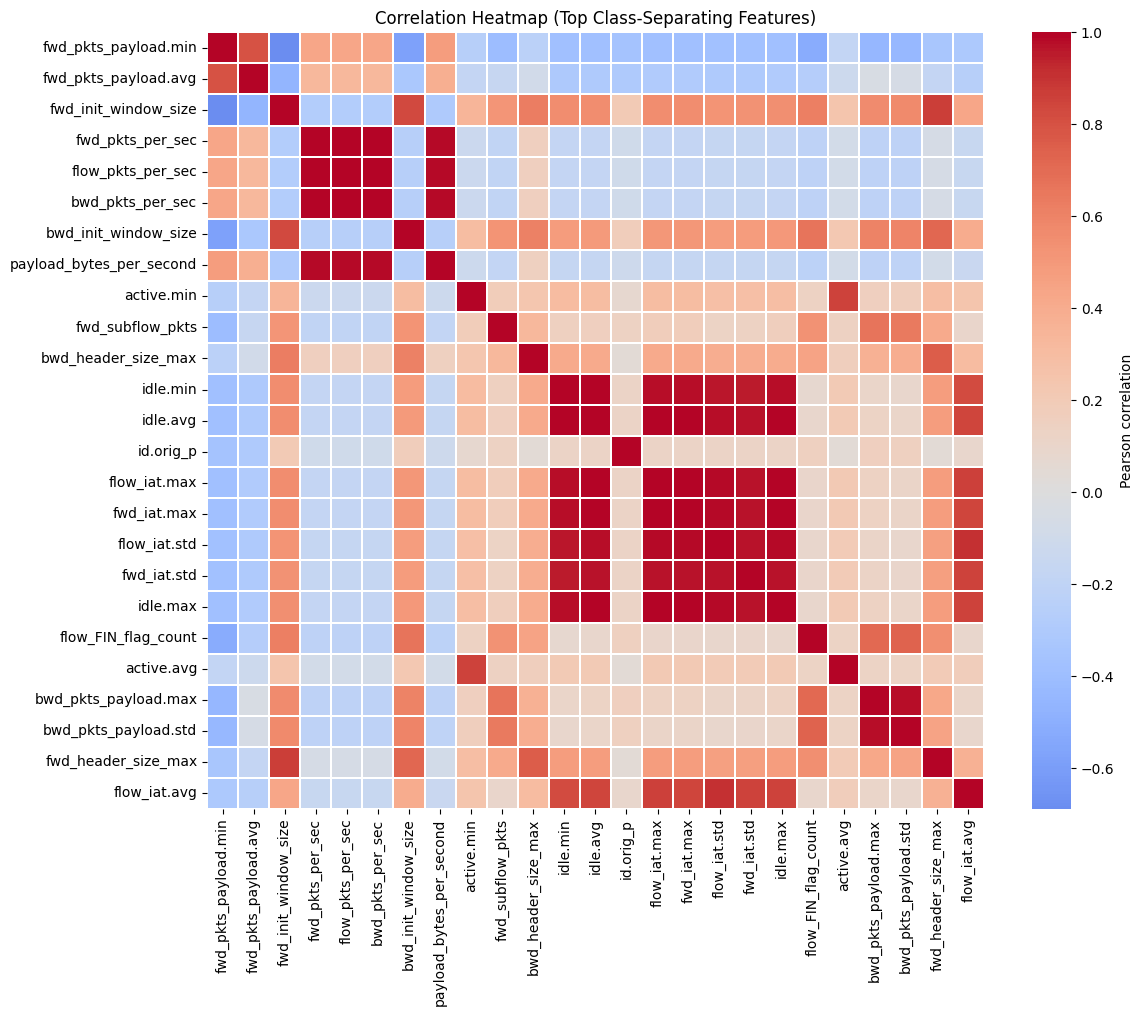

In [25]:
#| label: fig-rtiot-corr-heatmap
#| fig-cap: "Correlation heatmap of top 25 class-separating numeric features (by effect size)"

CORR_TOP_K = 25

CORR_FEATURES = (
    effect_scores
        .head(CORR_TOP_K)
        .index
)

corr = X_num[CORR_FEATURES].corr(method="pearson")

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Correlation Heatmap (Top Class-Separating Features)")
plt.tight_layout()
plt.show()

In [29]:
#| label: tbl-rtiot-vif-summary
#| tbl-cap: "Variance Inflation Factor (VIF) summary for numeric features"

# Copy numeric features for VIF calculation
X_vif = X_num.copy()

# Scale features for VIF stability
X_vif_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_vif),
    columns=X_vif.columns,
    index=X_vif.index
)

# Calculate VIF for each feature
vif_df = pd.DataFrame({
    "feature": X_vif_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_vif_scaled.values, i)
        for i in range(X_vif_scaled.shape[1])
    ]
}).sort_values("VIF", ascending=False)


# Split by VIF threshold
vif_high = vif_df[vif_df["VIF"] > 10].copy()
vif_acceptable = vif_df[vif_df["VIF"] <= 10].copy()

# Setup table for display
vif_summary_df = (
    pd.DataFrame({
        "Number of Features": [
            len(vif_high),
            len(vif_acceptable)
        ]
    },
    index=[
        "High multicollinearity (VIF > 10)",
        "Acceptable multicollinearity (VIF ≤ 10)"
    ])
    .rename_axis("VIF Category")
)

display(vif_summary_df)

c:\Users\joetn\anaconda3\envs\venv311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Number of Features
VIF Category,
High multicollinearity (VIF > 10),68
Acceptable multicollinearity (VIF ≤ 10),12


<Figure size 800x600 with 0 Axes>

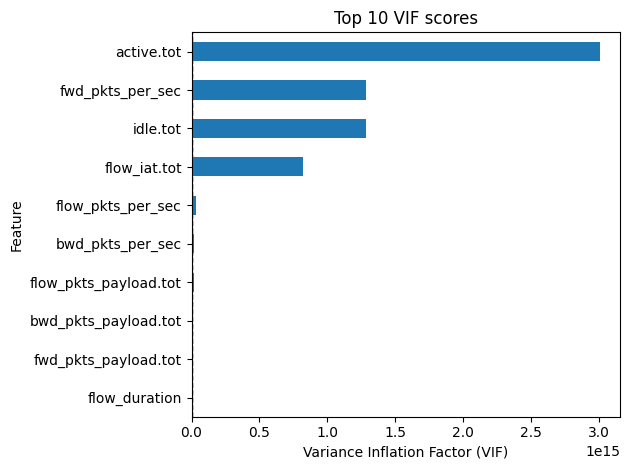

In [30]:
#| label: fig-rtiot-vif-top10
#| fig-cap: "Top 10 features by Variance Inflation Factor (VIF)"

# Select top 10 highest VIF features
top_vif = vif_df.head(10).iloc[::-1]

plt.figure(figsize=(8,6))

top_vif.plot(
    x="feature",
    y="VIF",
    kind="barh",
    legend=False
)

# Reference thresholds
plt.axvline(5, linestyle="--", linewidth=1)
plt.axvline(10, linestyle="--", linewidth=1)

plt.xlabel("Variance Inflation Factor (VIF)")
plt.ylabel("Feature")
plt.title("Top 10 VIF scores")

plt.tight_layout()
plt.show()

## Analysis of Top Features by Mutual Information

To quantify the predictive relevance of individual variables, **mutual information (MI)** was computed between each numeric feature and the attack labels. Mutual information measures how much knowing a feature reduces uncertainty about class membership, capturing **both linear and nonlinear dependencies** between network traffic characteristics and attack behavior.

Mutual information quantifies statistical dependence between a feature $X$ and the target variable $y$:

$$
I(X;Y)=\sum_{x,y} p(x,y)\log\frac{p(x,y)}{p(x)p(y)}.
$$

It can also be interpreted as a reduction in uncertainty:

$$
I(X;Y)=H(Y)-H(Y|X),
$$

where $H(Y)$ denotes entropy and $H(Y|X)$ represents conditional entropy. A value of $I(X;Y)=0$ implies statistical independence between $X$ and $Y$. Because mutual information captures both linear and nonlinear relationships, it is well suited for network traffic analysis, where attack behavior may alter packet statistics in complex, non-linear ways.

The top eight features ranked by mutual information as shown in @fig-rtiot-mi are:

- `fwd_pkts_payload.avg`
- `fwd_pkts_payload.max`
- `fwd_subflow_bytes`
- `flow_pkts_payload.tot`
- `fwd_pkts_payload.tot`
- `flow_pkts_payload.avg`
- `flow_pkts_payload.max`
- `id.resp_p`

1. **Strong Predictive Signal at the Feature Level:**

    All top-ranked features exhibit exceptionally high mutual information scores (≈ 0.85), indicating that **individual variables alone provide substantial information** about whether a flow corresponds to normal or attack traffic. This suggests that class separation in the RT-IoT 2022 dataset arises primarily from clear behavioral differences rather than subtle multivariate interactions.

    Notably, most high-ranking variables are derived from **packet payload statistics**, including averages, maxima, and total payload sizes. These measurements capture how data is transmitted within flows and appear to differ systematically between normal and attack traffic.

2. **Dominance of Payload-Based Traffic Characteristics:**

    The concentration of payload-related features among the top predictors indicates that attacks modify fundamental transmission behavior. Compared to normal traffic, attack flows tend to exhibit:

    - more consistent payload magnitudes,
    - structured packet generation patterns,
    - and reduced variability across packets within a flow.

    Such regularity is characteristic of automated attack tools, which generate traffic programmatically rather than through organic user-driven interactions.

3. **Evidence of Feature Redundancy:**

    Several top features **measure closely related quantities** (e.g., average, maximum, and total payload statistics). While each individually shows strong predictive power, their similarity suggests substantial redundancy. This implies that increasing the number of included features beyond the highest-ranked subset may provide diminishing returns, as additional variables often encode overlapping information about the same traffic behavior.

4. **Role of Network Context Features:**

    The inclusion of `id.resp_p` among the top predictors highlights the importance of network context alongside payload statistics. **Port information implicitly captures service-level behavior**, indicating that certain attack patterns are associated with specific communication protocols.

5. **Implications for Downstream Modeling:**

    The presence of highly informative individual features explains the strong performance observed with linear classifiers such as Logistic Regression. Because **substantial class separation exists at the feature level**, complex nonlinear models are not strictly required to achieve strong discrimination performance.

    From a practical standpoint, these findings suggest that a **compact subset of high-MI features may be sufficient for effective intrusion detection while reducing computational cost**. This observation is particularly relevant for subsequent deployment experiments targeting resource-constrained environments such as Raspberry Pi devices.

    Overall, mutual information analysis demonstrates that payload dynamics and flow-level transmission characteristics form the primary statistical signature distinguishing normal and attack traffic within the RT-IoT 2022 dataset.

In [31]:
# Calculate mutual information scores for numeric features
mi_scores = mutual_info_classif(
    X_num,
    y,
    random_state=RANDOM_STATE,
    discrete_features=False
)

mi_series = pd.Series(mi_scores, index=X_num.columns)\
                .sort_values(ascending=False)

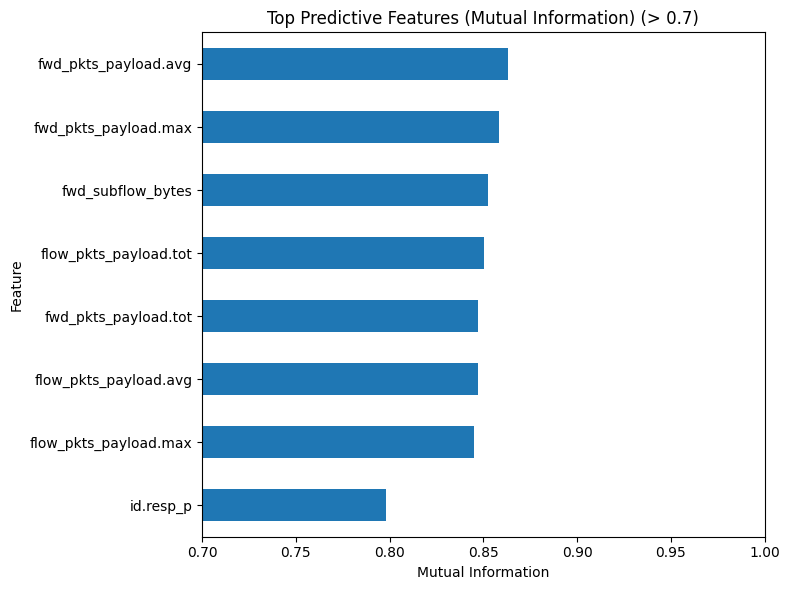

In [32]:
#| label: fig-rtiot-mi
#| fig-cap: "Top 8 features ranked by mutual information with the target label."
#| echo: false

plt.figure(figsize=(8,6))

mi_series.head(8).iloc[::-1].plot(kind="barh")

# Zoom into high-MI region
plt.xlim(0.7, 1.0)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Top Predictive Features (Mutual Information) (> 0.7)")
plt.tight_layout()
plt.show()

## PCA Analysis

1. The two-dimensional PCA projection in @fig-rtiot-pca shows partial separation between normal and attack traffic but with substantial overlap, indicating that the classes are **not linearly separable in low-dimensional space**. Normal traffic appears more concentrated, while attack samples exhibit greater dispersion and several extreme outliers, suggesting **higher variability in malicious network behavior**. This pattern supports the anomaly detection assumption that normal traffic follows more structured patterns whereas attacks deviate from learned behavior.

2. The cumulative explained variance analysis in @fig-rtiot-pca-variance indicates that **the dataset is intrinsically high-dimensional**. Although the first two principal components capture only about 31% of total variance, **approximately 20–30 components explain over 90–95% of the variance**. This suggests strong redundancy among features and implies that meaningful structure exists in a moderately compressed latent space, providing justification for dimensionality reduction and representation-learning approaches such as autoencoders.

In [33]:
# Clean numeric data for PCA (drop rows with any missing values)
X_num_clean = X_num.dropna(axis=0)
y_clean = df.loc[X_num_clean.index, TARGET_COL]

# Standardize features (required for PCA on mixed-scale features)
X_scaled = StandardScaler().fit_transform(X_num_clean)

# PCA (2D projection)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

evr_2d = pca_2d.explained_variance_ratio_

pca_2d_df = pd.DataFrame(
    {"PC1": X_pca_2d[:, 0], "PC2": X_pca_2d[:, 1], TARGET_COL: y_clean.values},
    index=X_num_clean.index
)

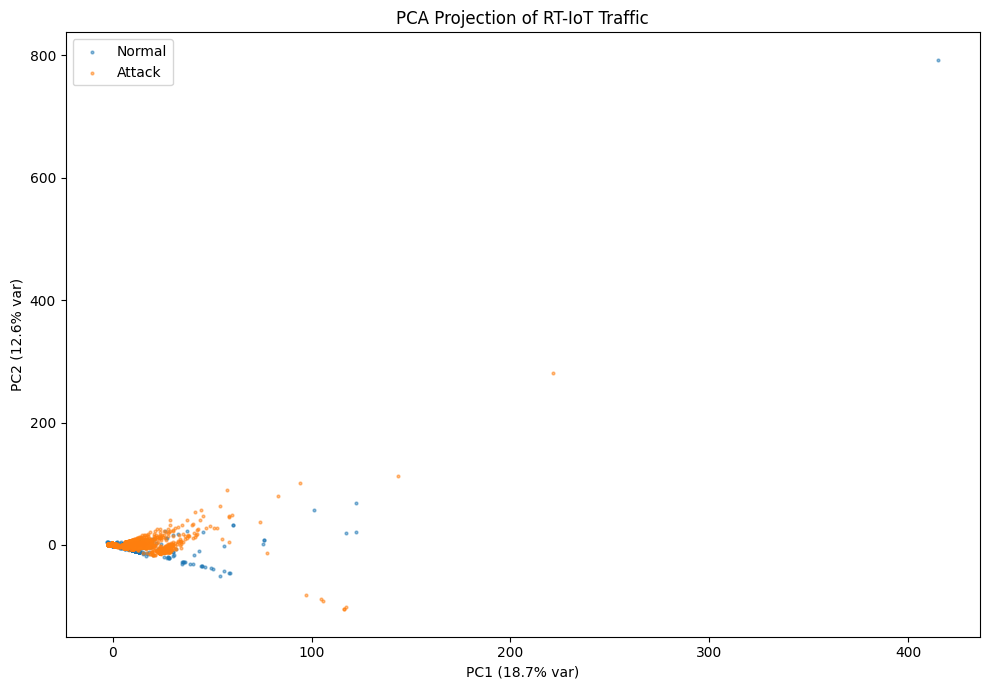

In [34]:
#| label: fig-rtiot-pca
#| fig-cap: "PCA projection of RT-IoT traffic (2D) colored by normal vs attack classes. Explained variance ratios for PC1 and PC2 are indicated in the axis labels."

# PCA scatter plot
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_2d_df.loc[NORMAL_MASK, "PC1"],
    pca_2d_df.loc[NORMAL_MASK, "PC2"],
    s=4, alpha=0.5, label="Normal"
)

plt.scatter(
    pca_2d_df.loc[ATTACK_MASK, "PC1"],
    pca_2d_df.loc[ATTACK_MASK, "PC2"],
    s=4, alpha=0.5, label="Attack"
)

plt.xlabel(f"PC1 ({evr_2d[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({evr_2d[1]*100:.1f}% var)")
plt.title("PCA Projection of RT-IoT Traffic")
plt.legend()
plt.tight_layout()
plt.show()

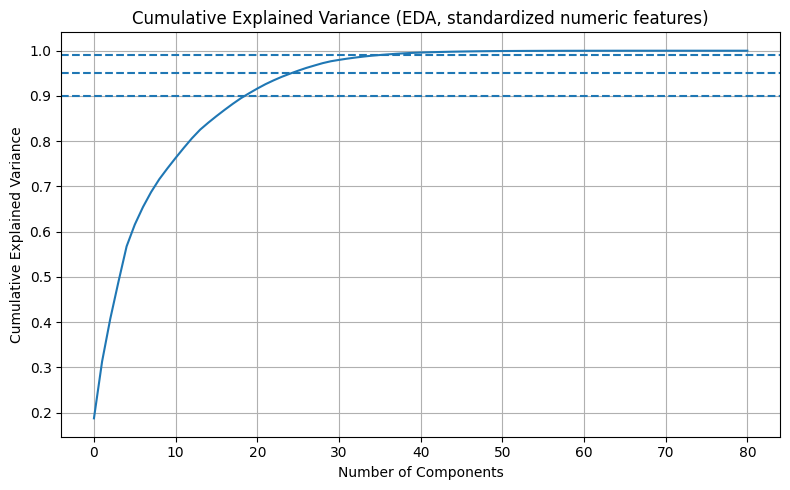

In [35]:
#| label: fig-rtiot-pca-variance
#| fig-cap: "Cumulative explained variance of RT-IoT traffic features. Horizontal dashed lines indicate common thresholds (90%, 95%, 99%) for intrinsic dimensionality estimation."

# Cumulative explained variance (intrinsic dimensionality proxy)
pca_full = PCA().fit(X_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(cum)
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.axhline(0.99, linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance (EDA, standardized numeric features)")
plt.grid(True)
plt.tight_layout()
plt.show()